In [2]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [3]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]

File 0: /Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc
<xarray.Dataset>
Dimensions:            (station: 9, valid_time: 750192)
Coordinates:
  * station            (station) int64 1 2 3 4 5 6 7 8 10
  * valid_time         (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-30T...
    latitude           float64 ...
    longitude          float64 ...
    station_latitude   (station) float64 ...
    station_longitude  (station) float64 ...
Data variables: (12/14)
    u10                (station, valid_time) float32 ...
    v10                (station, valid_time) float32 ...
    d2m                (station, valid_time) float32 ...
    t2m                (station, valid_time) float32 ...
    msl                (station, valid_time) float32 ...
    sst                (station, valid_time) float32 ...
    ...                 ...
    mwd                (station, valid_time) float32 ...
    mwp                (station, valid_time) float32 ...
    swh                (station, valid_

In [4]:
def preprocess(ds):
    return ds.sortby("station") 

datasets = [preprocess(xr.open_dataset(f)) for f in files]
ds = xr.concat(datasets, dim="station")

In [5]:
# Ensure time is sorted (important for derivatives)
ds = ds.sortby("valid_time")

# --- Core helpers (finite differences over hours) ---
def diff_hours(da, hours: int):
    """Finite-difference derivative over 'hours' (value change per hour)."""
    return (da - da.shift(valid_time=hours)) / hours

# --- Wind features ---
u = ds["u10"]
v = ds["v10"]
wind_speed = np.hypot(u, v).rename("wind_speed")

d_wind_1h = diff_hours(wind_speed, 1).rename("d_wind_1h")   # Δwind / 1h
d_wind_6h = diff_hours(wind_speed, 6).rename("d_wind_6h")   # Δwind / 6h

# --- Pressure derivatives (dsp/dt) ---
sp = ds["sp"]
d_sp_1h = diff_hours(sp, 1).rename("d_sp_1h")
d_sp_6h = diff_hours(sp, 6).rename("d_sp_6h")

# --- Tide shifted features ---
tide_lag1h = ds["tide"].shift(valid_time=1).rename("tide_lag1h")
tide_lag6h = ds["tide"].shift(valid_time=6).rename("tide_lag6h")
tide_lag0h = ds["tide"].shift(valid_time=0).rename("tide_lag0h")

# Make sure sorted
ds = ds.sortby("valid_time")

# Pull just tide to a tidy frame
df = ds[["tide"]].to_dataframe().reset_index()
df = df.sort_values(["station", "valid_time"])

# Compute tidal range per station (across all valid_time)
tide_range = (ds["tide"].max(dim="valid_time") - ds["tide"].min(dim="valid_time"))
tide_range = tide_range.rename("tide_range")

# --- Air density (rho_air) ---
# Use sp (Pa) and t2m (K) if available; else fallback to 1.225 kg/m^3
R_d = 287.05  # J kg^-1 K^-1
if "sp" in ds and "t2m" in ds:
    rho_air = (ds["sp"] / (R_d * ds["t2m"])).astype("float32").rename("rho_air")
else:
    rho_air = xr.zeros_like(wind_speed) + 1.225
    rho_air = rho_air.astype("float32").rename("rho_air")

# --- Drag coefficient C_D (Large & Pond style) ---
U = wind_speed
Cd = xr.where(
    U < 11.0,
    1.14e-3,
    xr.where(U <= 25.0, (0.49 + 0.065 * U) * 1e-3, 2.0e-3)
).astype("float32").rename("Cd")

# --- Wind stress components (N/m^2 = Pa) ---
tau_x = (rho_air * Cd * U * u).astype("float32").rename("tau_x")
tau_y = (rho_air * Cd * U * v).astype("float32").rename("tau_y")
tau_mag = (rho_air * Cd * U**2).astype("float32").rename("tau_mag")

# Optional: tendencies (change over 1h/6h), consistent with your diff_hours helper
tau_d1h = diff_hours(tau_mag, 1).astype("float32").rename("d_tau_1h")
tau_d6h = diff_hours(tau_mag, 6).astype("float32").rename("d_tau_6h")

# --- Assemble into one dataset ---
feat_ds = xr.Dataset(
    {
        "wind_speed": wind_speed,
        "d_wind_1h": d_wind_1h,
        "d_wind_6h": d_wind_6h,
        "d_sp_1h": d_sp_1h,
        "d_sp_6h": d_sp_6h,
        "tide_range_12h": tide_range,
        "tide_lag0h": tide_lag0h,
        "tide_lag1h": tide_lag1h,
        "tide_lag6h": tide_lag6h,
        # "d_msl_1h": d_msl_1h,  # uncomment if you computed these
        # "d_msl_6h": d_msl_6h,
        "tau_x": tau_x,
        "tau_y": tau_y,
        "tau_mag": tau_mag,
        "tau_d1h": tau_d1h,
        "tau_d6h": tau_d6h,
    }
)

# Keep original coordinates/attrs
feat_ds = feat_ds.assign_coords(
    station=ds["station"],
    valid_time=ds["valid_time"]
)
for v in feat_ds.data_vars:
    feat_ds[v].attrs.update(ds[v.split("_")[0]].attrs if v.split("_")[0] in ds.data_vars else {})

# Merge features back with original dataset (optional)
ds_engineered = xr.merge([ds, feat_ds])

In [6]:
# exclude target + sea_level + tide from predictors
predictors = [v for v in ds_engineered.data_vars if v not in ["residual", "sea_level", "tide", "longitude", "latitude", "station_longitude", "station_latitude", "station", "valid_time"]]
target = "residual"
df = ds_engineered[predictors + [target]].to_dataframe().reset_index()
df = df.dropna(subset=[target])

# Integrate all factors

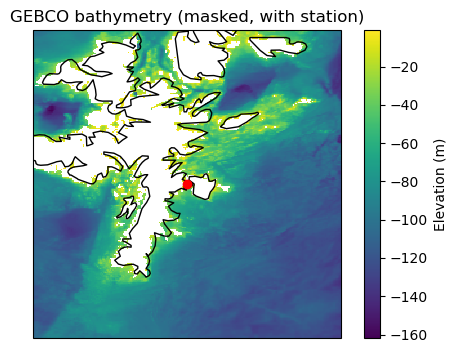

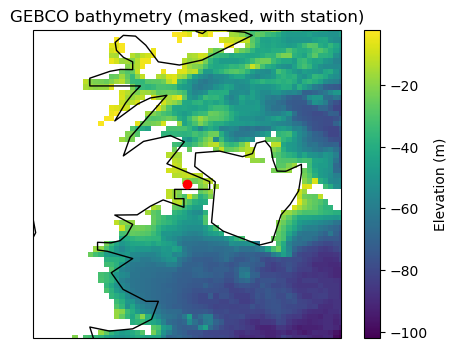

In [7]:

# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

#ds = xr.open_mfdataset(nc_files, combine='by_coords')  # or combine='nested' with concat_dim='time' if needed
ds_sealevel = xr.open_dataset("/Users/lb962/Documents/GitHub/ESL/data/processed/filtered_GESLA_sea_level.nc")
# extract station ids and their lat/lon
stations = ds_sealevel['station'].values
lats = ds_sealevel['latitude'].values
lons = ds_sealevel['longitude'].values

# build mapping from (lat, lon) to station index
latlon_to_station = {
    (float(lat), float(lon)): int(stn)
    for stn, lat, lon in zip(stations, lats, lons)
}

# if you want unique lat/lon pairs:
unique_latlon = list(latlon_to_station.keys())

# Function to extract square around a lat/lon
def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat + half, lat - half),  # GEBCO lat usually descending
        lon=slice(lon - half, lon + half),
        method="nearest"
    )

results = {
    "0.1x0.1": [],
    "0.25x0.25": [],
    "1x1": [],
    "3x3": [],
    "10x10":[]
}
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    return ds_tile.assign(elevation=ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5))

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()

def extract_square(ds, lat, lon, size_deg):
    """Fast spatial slice using coordinate indices."""
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat - half, lat + half),
        lon=slice(lon - half, lon + half)
    )

# --- Prep: ensure coordinates are monotonic so .sel(slice) is efficient ---
GEBCO_ds = GEBCO_ds.sortby(["lat", "lon"])

# Available resolutions (keep all for each point)
resolutions = [0.1, 0.25, 1.0, 3.0, 10.0]

# Initialize results dict
results = {f"{r}x{r}": [] for r in resolutions}
#results = {r: [] for r in resolutions}

# Build tiles for every (lat, lon) at every resolution
for lat, lon in unique_latlon:
    for size in resolutions:
        key = f"{size}x{size}"
        results[key].append(extract_square(GEBCO_ds, lat, lon, size))

# Example usage:
plot_tile(results["1.0x1.0"][0])
plot_tile(results["0.25x0.25"][0])

In [8]:
import numpy as np
import xarray as xr

def to_128x128(ds_tile: xr.Dataset, H: int = 224, W: int = 224) -> xr.Dataset:
    """
    Quick, vectorized resize of a GEBCO tile to (H,W) using xarray's interp.
    Works for all numeric vars defined on (lat, lon). Keeps dask laziness.
    """
    # Build uniform target coords spanning the tile extent (ascending)
    lat0, lat1 = float(ds_tile.lat.min()), float(ds_tile.lat.max())
    lon0, lon1 = float(ds_tile.lon.min()), float(ds_tile.lon.max())
    new_lat = np.linspace(lat0, lat1, H, dtype=np.float32)
    new_lon = np.linspace(lon0, lon1, W, dtype=np.float32)

    # Interpolate all variables defined on (lat, lon)
    return ds_tile.interp(lat=new_lat, lon=new_lon, method="linear")

# --- apply to every tile in your dict ---
results_128 = {k: [to_128x128(ds) for ds in tiles] for k, tiles in results.items()}

# sanity check (first available tile per bucket should be 128x128)
for k, tiles in results_128.items():
    if tiles:
        shp = tiles[0]["elevation"].shape
        assert shp == (224, 224), f"{k} -> {shp}, expected (128, 128)"

In [9]:
import torch, json, os
import torch.nn as nn

# ---- Load checkpoint + config ----
save_dir = "mae_ckpt"
class TinyMAE(nn.Module):
    def __init__(self, D, hidden=128):
        super().__init__()
        self.enc = nn.Linear(D, hidden)
        self.dec = nn.Linear(hidden, D)
        self.act = nn.ReLU()

    def forward(self, x_in):
        return self.dec(self.act(self.enc(x_in)))


with open(os.path.join(save_dir, "config.json")) as f:
    cfg = json.load(f)

# Must match training architecture
model = TinyMAE(D=cfg["H"] * cfg["W"], hidden=cfg["hidden"])
ckpt = torch.load(os.path.join(save_dir, "mae_state.pt"), map_location="cpu")
model.load_state_dict(ckpt["state_dict"])
model.eval()

print("Loaded TinyMAE pre-trained model")


Loaded TinyMAE pre-trained model


In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

def try_collect_tiles_from_results():
    """Collect 2D elevation arrays from results[...] xarray tiles."""
    if "results" not in globals():
        raise NameError("`results` not found in globals.")
    key = "1x1" if "1x1" in results and results["1x1"] else next(iter(results.keys()))
    tiles = []
    for ds in results[key]:
        if "elevation" not in ds:
            continue
        arr = np.array(ds["elevation"].values)
        if arr.ndim == 2:
            tiles.append(arr.astype(np.float32))
    if not tiles:
        raise ValueError("No usable 2D elevation arrays found in results.")
    return tiles, f"from results['{key}'] ({len(tiles)} tiles)"

def make_synthetic_tiles(n=64, h=64, w=64, seed=0):
    """Synthetic bathymetry-like tiles with NaNs on 'land' (> -0.5 m)."""
    rng = np.random.default_rng(seed)
    tiles = []
    y = np.linspace(0, 3*np.pi, h)
    x = np.linspace(0, 3*np.pi, w)
    Y, X = np.meshgrid(y, x, indexing='ij')
    for _ in range(n):
        base = np.sin(X) * np.cos(Y)
        base += 0.3 * np.sin(3*X + 0.2) * np.cos(2*Y - 0.5)
        base += 0.1 * rng.normal(size=(h, w))
        elev = -1000 + 800 * base
        elev = np.where(elev <= -0.5, elev, np.nan)
        tiles.append(elev.astype(np.float32))
    return tiles, f"synthetic ({n} tiles, {h}x{w})"

def resize_bilinear(img, new_h, new_w):
    """Vectorized bilinear resize (2D array), NaNs interpolate too."""
    H, W = img.shape
    if H == new_h and W == new_w:
        return img.copy()
    yi = np.linspace(0, H - 1, new_h)
    xi = np.linspace(0, W - 1, new_w)
    y0 = np.floor(yi).astype(int); y1 = np.minimum(y0 + 1, H - 1)
    x0 = np.floor(xi).astype(int); x1 = np.minimum(x0 + 1, W - 1)
    wy = (yi - y0)[:, None]
    wx = (xi - x0)[None, :]
    I00 = img[y0[:, None], x0[None, :]]
    I01 = img[y0[:, None], x1[None, :]]
    I10 = img[y1[:, None], x0[None, :]]
    I11 = img[y1[:, None], x1[None, :]]
    return (1 - wy) * ((1 - wx) * I00 + wx * I01) + wy * ((1 - wx) * I10 + wx * I11)

class TileDataset(torch.utils.data.Dataset):
    def __init__(self, tiles, H=32, W=32, mask_ratio=0.75, seed=42):
        self.H, self.W = H, W
        self.mask_ratio = mask_ratio
        self.rng = np.random.default_rng(seed)

        X_list, V_list = [], []
        for img in tiles:
            img32 = resize_bilinear(np.asarray(img, dtype=np.float32), H, W)
            valid = ~np.isnan(img32)
            x = np.where(valid, img32, 0.0).astype(np.float32)
            X_list.append(x)
            V_list.append(valid.astype(np.float32))

        X = np.stack(X_list, 0)
        V = np.stack(V_list, 0)

        valid_sum = V.sum()
        mean = float((X * V).sum() / valid_sum)
        std = float(np.sqrt((((X - mean) * V) ** 2).sum() / valid_sum))
        X = (X - mean) / (std + 1e-8)

        self.X = torch.from_numpy(X)
        self.V = torch.from_numpy(V)
        self.N = self.X.shape[0]
        self.D = H * W

    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        x = self.X[idx]        # (H, W)
        v = self.V[idx]        # (H, W)
        m = (torch.rand_like(v) < self.mask_ratio).float()
        return x.view(-1), v.view(-1), m.view(-1)


class TinyMAE(nn.Module):
    def __init__(self, D, hidden=128):
        super().__init__()
        self.enc = nn.Linear(D, hidden)
        self.dec = nn.Linear(hidden, D)
        self.act = nn.ReLU()

    def forward(self, x_in):
        return self.dec(self.act(self.enc(x_in)))
H=128
W=128 
batch_size=32
mask_ratio= 0.75
seed=2025
torch.manual_seed(seed)
np.random.seed(seed)

ds = TileDataset(results_128, H=H, W=W, mask_ratio=mask_ratio, seed=seed)
loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

ValueError: could not convert string to float: '0.1x0.1'

In [50]:
import torch, json, os
import torch.nn as nn

# Load config
save_dir = "/Users/lb962/Documents/GitHub/ESL/notebooks/3_featureprocessing/mae_ckpt"
with open(os.path.join(save_dir, "config.json")) as f:
    cfg = json.load(f)


class MAE(nn.Module):
    def __init__(self, D, hidden=128):
        super().__init__()
        self.enc = nn.Linear(D, hidden)
        self.dec = nn.Linear(hidden, D)
        self.act = nn.ReLU()

    def forward(self, x_in):
        return self.dec(self.act(self.enc(x_in)))

# Recreate model with same hyperparameters
model = MAE(
    H=cfg["H"],
    W=cfg["W"],
    hidden=cfg["hidden"],
    mask_ratio=cfg["mask_ratio"]
)
model.load_state_dict(torch.load(os.path.join(save_dir, "mae_state.pt"))["state_dict"])

model.eval()  # switch to eval mode
print("Loaded pre-trained MAE from checkpoint")


TypeError: MAE.__init__() got an unexpected keyword argument 'H'

In [33]:
import torch.nn as nn
num_features = len(X_train.columns)
# From torchvision.models
from torchvision import models
model = models.resnet50(pretrained=False)

# Modify the model head for fine-tuning
model.fc = nn.Linear(num_features, 1) # Regression task has a single output

# Additional linear layer and dropout layer
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),  # Additional linear layer with 256 output features
    nn.ReLU(inplace=True),         # Activation function (you can choose other activation functions too)
    nn.Dropout(0.5),               # Dropout layer with 50% probability
    nn.Linear(256, 1)    # Final prediction fc layer
)

/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [36]:
import torch.optim as optim

# Define your optimizer with weight decay
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.001)

# Define your optimizer with weight decay
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)
# Define the loss function - For regression problem
loss_function = nn.MSELoss()  # Mean Squared Error loss

In [23]:
import numpy as np
import torch
from sklearn.base import BaseEstimator, TransformerMixin

def _numpy_tiles_to_tensor(X, H, W, device):
    """
    X: list/array of 2D float32 arrays (NaNs allowed).
    Returns torch tensor [N, 1, H, W] with NaNs zero-filled + mask (optional if you need it).
    """
    Xp = []
    for arr in X:
        a = np.asarray(arr, dtype=np.float32)
        # Replace NaNs with per-sample median for inference consistency
        if not np.isfinite(a).any():
            a = np.zeros((H, W), dtype=np.float32)
        else:
            med = np.nanmedian(a)
            a = np.where(np.isfinite(a), a, med).astype(np.float32)
        if a.shape != (H, W):
            # safety: resize with PIL bilinear (same as training helper)
            a_img = Image.fromarray(a)
            a = np.asarray(a_img.resize((W, H), Image.BILINEAR), dtype=np.float32)
        Xp.append(a[None, ...])  # [1, H, W]
    Xp = np.stack(Xp, axis=0)  # [N, 1, H, W]
    return torch.from_numpy(Xp).to(device)

class MAEEncoder(BaseEstimator, TransformerMixin):
    """
    sklearn Transformer: converts 2D tiles -> embedding vectors using your trained MAE.
    """
    def __init__(self, ckpt_path, H, W, device="cpu", agg="mean", try_full_model_path=None):
        self.ckpt_path = ckpt_path
        self.try_full_model_path = try_full_model_path  # optional fast path
        self.H, self.W = H, W
        self.device = device
        self.agg = agg  # "mean" or "flatten"

        self.model = None
        self._ready = False

    def _build_model(self):
        """
        Recreate the MAE architecture exactly as used in training.
        Implement this factory to match your `train_mae` model.
        """
        # ---- Example skeleton; replace with your actual model/build function ----
        # from your_lib import build_mae_model
        # model = build_mae_model(H=self.H, W=self.W, hidden=hidden, ...)
        # -----------------------------------------------------------------------
        raise NotImplementedError(
            "Please implement _build_model() to reconstruct your MAE architecture."
        )

    def _load(self):
        if self._ready:
            return
        if self.try_full_model_path:
            # Convenience route (works if you saved a full model object)
            try:
                self.model = torch.load(self.try_full_model_path, map_location=self.device)
                self.model.eval().to(self.device)
                self._ready = True
                return
            except Exception:
                pass

        # Standard portable route: rebuild + load state_dict
        state = torch.load(self.ckpt_path, map_location="cpu")
        self.model = self._build_model()
        self.model.load_state_dict(state["state_dict"])
        self.model.eval().to(self.device)
        self._ready = True

    @torch.no_grad()
    def _encode_tensor(self, x4d):
        """
        x4d: [N, 1, H, W], float32
        Returns: torch.Tensor [N, D]
        """
        m = self.model
        # Try common MAE encodings
        if hasattr(m, "encode") and callable(getattr(m, "encode")):
            z = m.encode(x4d)  # expect [N, Tokens, D] or [N, D, H', W'] or [N, D]
        elif hasattr(m, "encoder") and callable(getattr(m, "encoder")):
            z = m.encoder(x4d)
        else:
            # try forward with a flag
            try:
                z = m(x4d, return_latent=True)
            except TypeError:
                # last resort: take first output if tuple
                out = m(x4d)
                if isinstance(out, (tuple, list)) and len(out) > 1:
                    z = out[1]
                else:
                    z = out

        # Normalize shape to [N, D]
        if z.dim() == 4:  # [N, D, h, w] or [N, h, w, D]
            if z.shape[1] < z.shape[-1]:  # guess channel-first
                z = z.mean(dim=(2,3)) if self.agg == "mean" else z.flatten(1)
            else:  # channel-last
                if self.agg == "mean":
                    z = z.mean(dim=(1,2))
                else:
                    z = z.reshape(z.size(0), -1)
        elif z.dim() == 3:  # [N, Tokens, D]
            z = z.mean(dim=1) if self.agg == "mean" else z.flatten(1)
        elif z.dim() == 2:  # [N, D]
            pass
        else:
            raise RuntimeError(f"Unexpected latent shape: {tuple(z.shape)}")
        return z

    # ---- sklearn API ----
    def fit(self, X, y=None):
        self._load()
        return self

    def transform(self, X):
        """
        X: iterable of 2D arrays with shape ~ (H, W) (NaNs allowed)
        returns np.ndarray [N, D]
        """
        self._load()
        x4d = _numpy_tiles_to_tensor(X, self.H, self.W, self.device)
        with torch.no_grad():
            z = self._encode_tensor(x4d)
        return z.cpu().numpy()


embedder = MAEEncoder(
    ckpt_path="/Users/lb962/Documents/GitHub/ESL/notebooks/4_mlmodels/mae_ckpt/mae_state.pt",
    H=128, W=128,
    device="cpu",
    agg="mean",
    try_full_model_path="/Users/lb962/Documents/GitHub/ESL/notebooks/4_mlmodels/mae_ckpt/mae_state.pt",
)

In [24]:
embedder

MAEEncoder(H=128, W=128,
           ckpt_path='/Users/lb962/Documents/GitHub/ESL/notebooks/4_mlmodels/mae_ckpt/mae_state.pt',
           try_full_model_path='/Users/lb962/Documents/GitHub/ESL/notebooks/4_mlmodels/mae_ckpt/mae_state.pt')

In [1]:
# === Encode GEBCO tiles with your trained MAE and join to df ===
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image  # used by _numpy_tiles_to_tensor in MAEEncoder

# 1) Make sure embedder matches your trained model (32x32) and loads the saved full model
embedder = MAEEncoder(
    ckpt_path="mae_ckpt/mae_state.pt",         # portable state_dict (still saved)
    H=32, W=32,                                # <-- match training
    device="cpu",
    agg="mean",                                # mean-pooled latent (good for trees)
    try_full_model_path="mae_ckpt/mae_full_model.pt"  # fast path (no _build_model needed)
)

# 2) Helper: extract 2D array from an xarray tile
def ds_to_2d(ds_tile, var="elevation"):
    if var not in ds_tile:
        return None
    arr = np.asarray(ds_tile[var].values, dtype=np.float32)
    return arr if arr.ndim == 2 else None

# 3) Compute embeddings per resolution, preserving the tile order (== order of unique_latlon)
def compute_mae_embeddings(results_dict, embedder, var="elevation"):
    emb_per_res = {}  # { "0.25x0.25": np.ndarray [N_stations, D], ... }
    for key, tiles in results_dict.items():
        arrs = []
        for ds_tile in tiles:
            a = ds_to_2d(ds_tile, var)
            if a is not None:
                arrs.append(a)
        if not arrs:
            continue
        Z = embedder.transform(arrs)  # [N, D]
        emb_per_res[key] = Z
        print(f"[{key}] -> embeddings {Z.shape}")
    return emb_per_res

emb_per_res = compute_mae_embeddings(results, embedder, var="elevation")

# 4) Build a station index list aligned with `results` order.
#    You created `unique_latlon` and `latlon_to_station` earlier; reuse them:
station_ids = [latlon_to_station[(float(lat), float(lon))] for (lat, lon) in unique_latlon]

# 5) Turn embeddings into DataFrames (one per resolution) and concat columns
dfs = []
for res_key, Z in sorted(emb_per_res.items(), key=lambda kv: float(kv[0].split('x')[0])):
    D = Z.shape[1]
    cols = [f"mae_{res_key}_f{j:03d}" for j in range(D)]
    df_res = pd.DataFrame(Z, columns=cols)
    df_res.insert(0, "station", station_ids)  # align by station id
    dfs.append(df_res)

# Combine all resolutions’ features side-by-side
emb_df = dfs[0]
for add_df in dfs[1:]:
    # merge on station; avoid duplicate 'station' columns
    emb_df = emb_df.merge(add_df, on="station", how="inner")

print("MAE feature shape (per station):", emb_df.shape)

# 6) Join onto your main df (adds columns for every row by station)
df = df.merge(emb_df, on="station", how="left")

# 7) Update predictor list with the new MAE columns
mae_cols = [c for c in df.columns if c.startswith("mae_")]
predictors = list(sorted(set(predictors).union(mae_cols)))

# now your existing split/train code works unchanged:
# X_train, y_train = df.loc[m_train, predictors], df.loc[m_train, target]
# X_val,   y_val   = df.loc[m_val,   predictors], df.loc[m_val,   target]


NameError: name 'MAEEncoder' is not defined

In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
RANDOM_SEED=42
def stats(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100.0
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_%": mape}

rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted(df["station"].unique()))
perm = rng.permutation(stations)

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.10 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = df["station"].isin(train_stn)
m_val   = df["station"].isin(val_stn)
m_test  = df["station"].isin(test_stn)

X_cols = predictors  # all other variables as predictors

X_train, y_train = df.loc[m_train, X_cols], df.loc[m_train, target]
X_val,   y_val   = df.loc[m_val,   X_cols], df.loc[m_val,   target]
X_test,  y_test  = df.loc[m_test,  X_cols], df.loc[m_test,  target]

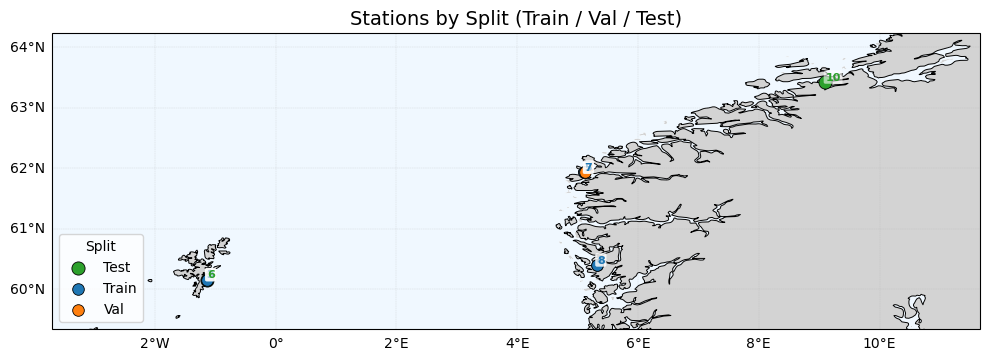

Saved: station_split_map.png


In [20]:
# pip install cartopy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1) Unique stations with coordinates
st_meta = (
    df[["station", "station_latitude", "station_longitude"]]
    .dropna(subset=["station_latitude", "station_longitude"])
    .drop_duplicates(subset=["station"])
    .sort_values("station")
    .reset_index(drop=True)
)

# 2) Add split label
def split_label(s):
    if s in train_stn: return "train"
    if s in val_stn:   return "val"
    if s in test_stn:  return "test"
    return "unknown"

st_meta["split"] = st_meta["station"].apply(split_label)

# 3) Map setup
lon_min, lon_max = st_meta["station_longitude"].min(), st_meta["station_longitude"].max()
lat_min, lat_max = st_meta["station_latitude"].min(),  st_meta["station_latitude"].max()

# pad the extent a bit
d_lon = (lon_max - lon_min) or 1.0
d_lat = (lat_max - lat_min) or 1.0
pad = 0.25
extent = [lon_min - pad*d_lon, lon_max + pad*d_lon,
          lat_min - pad*d_lat, lat_max + pad*d_lat]

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=proj)
ax.set_extent(extent, crs=proj)

# basemap features
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--")
gl.right_labels = False
gl.top_labels = False

# 4) Plot by split
colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:green", "unknown": "gray"}
sizes  = {"train": 70, "val": 70, "test": 90, "unknown": 60}  # make test a bit bigger

for split, df_split in st_meta.groupby("split"):
    ax.scatter(
        df_split["station_longitude"], df_split["station_latitude"],
        s=sizes.get(split, 70),
        color=colors.get(split, "gray"),
        edgecolor="k",
        linewidth=0.6,
        transform=proj,
        zorder=5,
        label=split.capitalize()
    )

# 5) Optional: label station IDs
label_points = True
if label_points:
    for _, r in st_meta.iterrows():
        ax.text(
            r["station_longitude"], r["station_latitude"],
            f'{int(r["station"])}',
            transform=proj,
            fontsize=8, weight="bold",
            ha="left", va="bottom",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6),
            zorder=6,
            color=colors.get(r["split"], "black")
        )

# legend & title
handles, labels = ax.get_legend_handles_labels()
# deduplicate legend entries
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc="lower left", title="Split")
plt.title("Stations by Split (Train / Val / Test)", fontsize=14)
plt.tight_layout()
plt.savefig("station_split_map.png", dpi=150)
plt.show()

print("Saved: station_split_map.png")


In [37]:
# ---------------------------
# 4) XGBoost model
# ---------------------------
model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.02,
    max_depth=10,
    subsample=1,
    colsample_bytree=0.6,
    reg_lambda=5,
    min_child_weight= 6,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    gamma=0.0,
    tree_method="hist",   # fast and memory-efficient
)

# XGBoost natively handles NaNs in features
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          verbose=False)

# ---------------------------
# 5) Evaluate
# ---------------------------
def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance:")
_ = evaluate("Train", X_train, y_train, model)
_ = evaluate(" Val ", X_val,   y_val,   model)
test_pred = evaluate("Test ", X_test,  y_test,  model)

# ---------------------------
# 6) Save model + test predictions
# ---------------------------
#joblib.dump({"model": model, "features": X_cols}, "xgb_residual_model.joblib")
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: xgb_residual_model.joblib")
print("Saved: test_predictions.parquet")

Performance:
Train | R2: 0.6187 | MAE: 0.0734
 Val  | R2: 0.8074 | MAE: 0.0528
Test  | R2: 0.4009 | MAE: 0.1192
Saved: xgb_residual_model.joblib
Saved: test_predictions.parquet


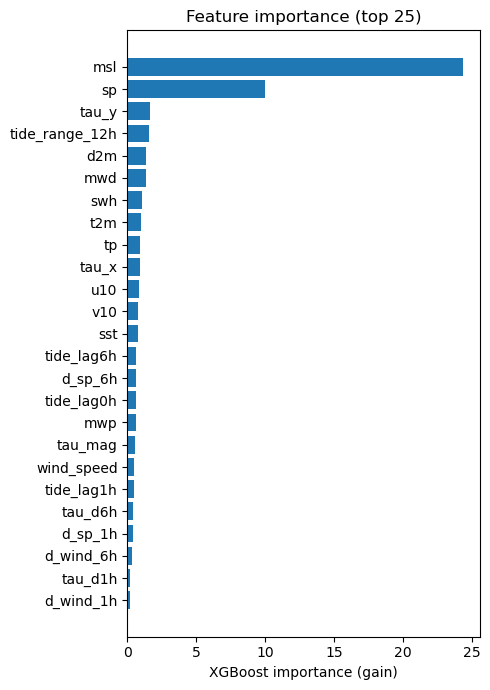

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# Choose which importance definition you want: 'gain', 'weight', 'cover', 'total_gain', 'total_cover'
importance_type = 'gain'

# Grab importance from booster with your feature names
booster = model.get_booster()
# X_cols should be a list-like of your training column names (order must match X_train)
booster.feature_names = list(map(str, X_cols))

score_dict = booster.get_score(importance_type=importance_type)
# Ensure all features appear (fill missing with 0)
imp = np.array([score_dict.get(str(f), 0.0) for f in X_cols], dtype=float)

order = np.argsort(imp)[::-1]
top_k = 30  # show top-N
order = order[:top_k]

plt.figure(figsize=(5, max(2, 0.28*len(order))))
plt.barh(np.array(X_cols)[order][::-1], imp[order][::-1])
plt.xlabel(f"XGBoost importance ({importance_type})")
plt.title("Feature importance (top {})".format(len(order)))
plt.tight_layout()
plt.show()


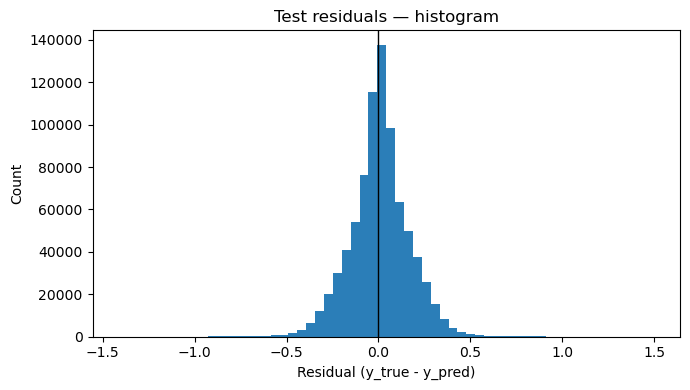

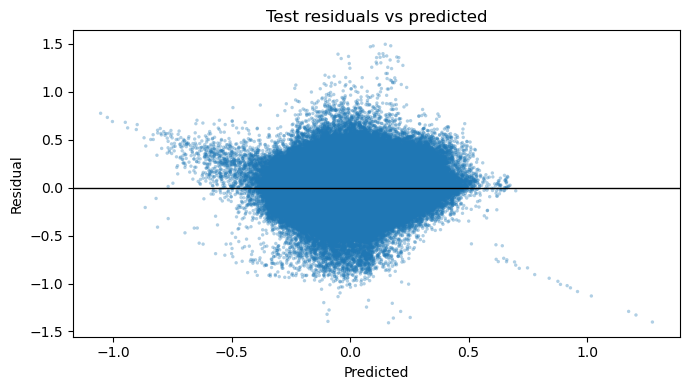

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# If starting fresh, load what you saved:
# out = pd.read_parquet("test_predictions.parquet")

# Make sure the columns are named consistently
preds = out.rename(columns={"residual_pred": "y_pred", target: "y_true"}).copy()
preds["valid_time"] = pd.to_datetime(preds["valid_time"])
preds["residual"] = preds["y_true"] - preds["y_pred"]

# --- A) Residual histogram ---
plt.figure(figsize=(7,4))
plt.hist(preds["residual"].dropna(), bins=60, alpha=0.95)
plt.axvline(0, color="k", lw=1)
plt.xlabel("Residual (y_true - y_pred)")
plt.ylabel("Count")
plt.title("Test residuals — histogram")
plt.tight_layout()
plt.show()

# --- B) Residuals vs Predicted (heteroscedasticity check) ---
plt.figure(figsize=(7,4))
plt.scatter(preds["y_pred"], preds["residual"], s=6, alpha=0.35, edgecolors="none")
plt.axhline(0, color="k", lw=1)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Test residuals vs predicted")
plt.tight_layout()
plt.show()


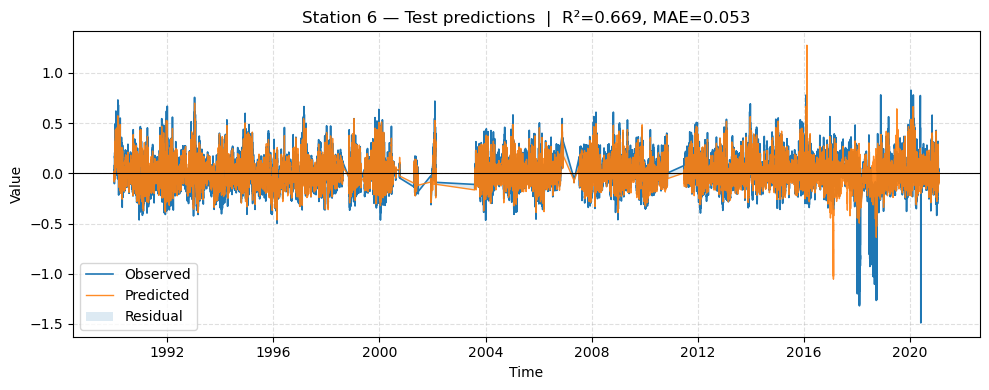

In [45]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id):
    g = preds[preds["station"] == station_id].sort_values("valid_time")
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.axhline(0, color="k", lw=0.8)
    plt.title(f"Station {station_id} — Test predictions  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value"); plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example:
plot_station_residuals(preds['station'].iloc[0])


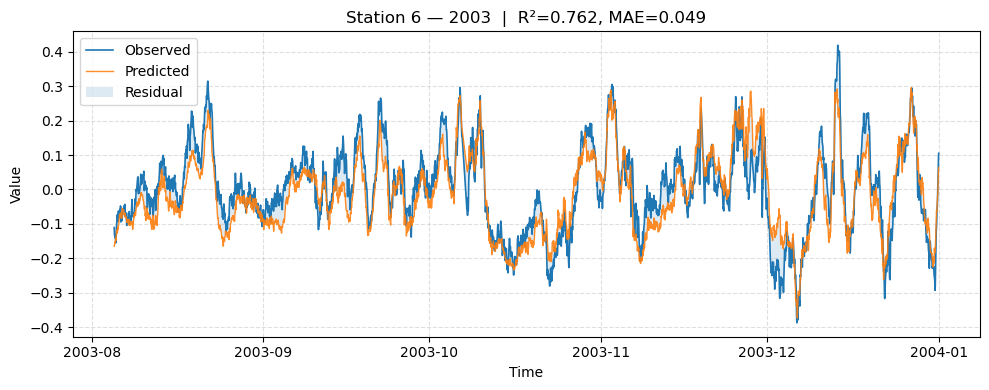

In [51]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id, year=None):
    g = preds[preds["station"] == station_id].sort_values("valid_time").copy()
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    
    if year is not None:
        g = g[g["valid_time"].dt.year == year]
        if g.empty:
            print(f"No test rows for station {station_id} in year {year}")
            return
    
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.title(f"Station {station_id} — {year if year else 'Full period'}  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value")
    plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example: first station in 2017
plot_station_residuals(preds['station'].iloc[0], year=2003)


In [ ]:
# --- replace your Section 4–6 with this MLP version ---

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd

# 4) MLP model (with impute+scale)
mlp_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler(with_mean=True, with_std=True)),
    ("mlp",     MLPRegressor(
        hidden_layer_sizes=(256, 128, 64),  # try (256,128) or (512,256,128) if you want more capacity
        activation="relu",
        solver="adam",
        alpha=1e-4,              # L2 weight decay
        learning_rate_init=1e-3,
        batch_size=2048,         # tune depending on RAM
        max_iter=200,            # optimizer steps (epochs)
        early_stopping=True,     # uses 10% of TRAIN as internal validation
        n_iter_no_change=15,
        validation_fraction=0.1,
        shuffle=True,
        random_state=RANDOM_SEED,
        verbose=False,
    ))
])

mlp_pipe.fit(X_train, y_train)

# 5) Evaluate
def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance (MLP):")
_ = evaluate("Train", X_train, y_train, mlp_pipe)
_ = evaluate(" Val ", X_val,   y_val,   mlp_pipe)
test_pred = evaluate("Test ", X_test,  y_test,  mlp_pipe)

# 6) Save test predictions (same as before)
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: test_predictions.parquet")

/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Performance (MLP):


In [ ]:
# pip install tensorflow scikit-learn numpy pandas

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras

# ---------------------------
# 0) Config
# ---------------------------
LOOKBACK = 72          # timesteps per sample (e.g., 72 hours)
BATCH_SIZE = 256
EPOCHS = 40
RANDOM_SEED = 1        # you already set this above
TARGET = target        # "residual"
FEATURES = X_cols      # your predictors (exclude residual/sea_level/tide)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ---------------------------
# 1) Prepare tidy frames (same split you already created)
# ---------------------------
def tidy(df_part):
    # ensure sorted by (station, time)
    return (df_part[["station","valid_time"] + FEATURES + [TARGET]]
            .sort_values(["station","valid_time"])
            .reset_index(drop=True))

train_df = tidy(df.loc[m_train])
val_df   = tidy(df.loc[m_val])
test_df  = tidy(df.loc[m_test])

# ---------------------------
# 2) Impute & scale features (fit on TRAIN stations only)
# ---------------------------
imp = SimpleImputer(strategy="median")
sc  = StandardScaler()

Xtr = imp.fit_transform(train_df[FEATURES])
Xtr = sc.fit_transform(Xtr)

Xva = sc.transform(imp.transform(val_df[FEATURES]))
Xte = sc.transform(imp.transform(test_df[FEATURES]))

ytr = train_df[TARGET].values
yva = val_df[TARGET].values
yte = test_df[TARGET].values

# Keep ids to map predictions back
id_tr = train_df[["station","valid_time"]].values
id_va = val_df[["station","valid_time"]].values
id_te = test_df[["station","valid_time"]].values

# ---------------------------
# 3) Build sequences per station (no cross-station mixing)
# ---------------------------
def make_sequences(X, y, ids, stations, lookback=72):
    """
    X: np.array [n, p]
    y: np.array [n]
    ids: array of [station, timestamp]
    stations: array same length as X of station ids
    returns: X_seq [m, lookback, p], y_seq [m], ids_seq [m, 2]
    """
    X_list, y_list, id_list = [], [], []
    # indices per station in contiguous blocks (data are sorted)
    stn = stations.reshape(-1)
    _, start_idx, counts = np.unique(stn, return_counts=True, return_index=True)
    for s_idx, cnt in zip(start_idx, counts):
        lo, hi = s_idx, s_idx + cnt
        Xi, yi, idi = X[lo:hi], y[lo:hi], ids[lo:hi]
        if len(Xi) < lookback: 
            continue
        # sliding window within this station only
        for t in range(lookback-1, len(Xi)):
            X_list.append(Xi[t-lookback+1:t+1, :])
            y_list.append(yi[t])                 # predict residual at time t
            id_list.append(idi[t])               # (station, valid_time at t)
    if not X_list:
        return (np.empty((0, lookback, X.shape[1]), dtype=np.float32),
                np.empty((0,), dtype=np.float32),
                np.empty((0, 2), dtype=object))
    return (np.asarray(X_list, dtype=np.float32),
            np.asarray(y_list, dtype=np.float32),
            np.asarray(id_list, dtype=object))

# station arrays (sorted already)
st_tr = train_df["station"].values
st_va = val_df["station"].values
st_te = test_df["station"].values

Xtr_seq, ytr_seq, idtr_seq = make_sequences(Xtr, ytr, id_tr, st_tr, LOOKBACK)
Xva_seq, yva_seq, idva_seq = make_sequences(Xva, yva, id_va, st_va, LOOKBACK)
Xte_seq, yte_seq, idte_seq = make_sequences(Xte, yte, id_te, st_te, LOOKBACK)

print(f"Seq shapes -> train: {Xtr_seq.shape}, val: {Xva_seq.shape}, test: {Xte_seq.shape}")

# ---------------------------
# 4) tf.data pipelines
# ---------------------------
def ds_from_arrays(X, y, batch):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    return ds.shuffle(len(X), seed=RANDOM_SEED).batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds = ds_from_arrays(Xtr_seq, ytr_seq, BATCH_SIZE)
val_ds   = tf.data.Dataset.from_tensor_slices((Xva_seq, yva_seq)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((Xte_seq, yte_seq)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# ---------------------------
# 5) LSTM model
# ---------------------------
n_features = Xtr_seq.shape[-1]
inp = keras.Input(shape=(LOOKBACK, n_features))
x = keras.layers.LSTM(128, return_sequences=True)(inp)
x = keras.layers.LSTM(64)(x)
x = keras.layers.Dense(64, activation="relu")(x)
out = keras.layers.Dense(1)(x)

model = keras.Model(inp, out)
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")

callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=1)

# ---------------------------
# 6) Evaluate (MAE / RMSE / R2) and save predictions
# ---------------------------
def evaluate(name, ds, y_true, ids_arr):
    y_pred = model.predict(ds, verbose=0).ravel()
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:>5} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
    pred_df = pd.DataFrame(ids_arr, columns=["station","valid_time"])
    pred_df["valid_time"] = pd.to_datetime(pred_df["valid_time"])
    pred_df["residual"] = y_true
    pred_df["residual_pred"] = y_pred
    return pred_df

print("Performance (LSTM):")
train_pred_df = evaluate("Train", train_ds, ytr_seq, idtr_seq)
val_pred_df   = evaluate(" Val ", val_ds,   yva_seq, idva_seq)
test_pred_df  = evaluate("Test ", test_ds,  yte_seq, idte_seq)

# Save test predictions like before (station, valid_time, residual, residual_pred)
test_pred_df.sort_values(["station","valid_time"]).to_parquet("test_predictions_lstm.parquet", index=False)
print("Saved: test_predictions_lstm.parquet")

# Optional: plot training curves
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.plot(history.history["loss"], label="Train MAE")
plt.plot(history.history["val_loss"], label="Val MAE")
plt.xlabel("Epoch"); plt.ylabel("MAE"); plt.title("LSTM Training"); plt.legend(); plt.tight_layout()
plt.savefig("lstm_training_curve.png", dpi=150); plt.show()
print("Saved: lstm_training_curve.png")


In [ ]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib matplotlib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
import matplotlib.pyplot as plt
import joblib

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc"
RANDOM_SEED = 42
target = "residual"

# ---------------------------
# 1) Load (no Dask) & prepare predictors
# ---------------------------
ds = xr.open_dataset(PATH)
ds.load()

# exclude target + sea_level + tide from predictors
predictors = [v for v in ds.data_vars if v not in ["residual", "sea_level", "tide"]]

df = ds[predictors + [target]].to_dataframe().reset_index()
df = df.dropna(subset=[target])

# ---------------------------
# 2) Station split (70/20/10)
# ---------------------------
rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted(df["station"].unique()))
perm = rng.permutation(stations)

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.20 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = df["station"].isin(train_stn)
m_val   = df["station"].isin(val_stn)
m_test  = df["station"].isin(test_stn)

X_cols = predictors

X_train, y_train = df.loc[m_train, X_cols], df.loc[m_train, target]
X_val,   y_val   = df.loc[m_val,   X_cols], df.loc[m_val,   target]
X_test,  y_test  = df.loc[m_test,  X_cols], df.loc[m_test,  target]

# ---------------------------
# 3) Hyperparameter tuning with Grouped CV (by station)
# ---------------------------
# Ensure CV folds do not mix stations:
groups = df.loc[m_train, "station"].values
n_splits = max(2, min(3, len(train_stn)))   # at least 2 splits
cv = GroupKFold(n_splits=n_splits)

base_est = XGBRegressor(
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="hist",     # fast & memory-efficient
    objective="reg:squarederror",
)

param_dist = {
    "n_estimators":       [400, 600, 800, 1000, 1400],
    "learning_rate":      [0.02, 0.05, 0.08, 0.10],
    "max_depth":          [4, 6, 8, 10],
    "min_child_weight":   [1, 3, 6, 10],
    "subsample":          [0.7, 0.85, 1.0],
    "colsample_bytree":   [0.6, 0.8, 1.0],
    "reg_lambda":         [0.1, 1.0, 5.0, 10.0],
    "gamma":              [0.0, 0.1, 0.5, 1.0],
}

search = RandomizedSearchCV(
    estimator=base_est,
    param_distributions=param_dist,
    n_iter=24,                 # increase for a deeper search
    scoring="neg_mean_absolute_error",
    cv=cv,
    refit=True,                # refits on the full training set (m_train)
    verbose=1,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

search.fit(X_train, y_train, groups=groups)
best_params = search.best_params_
print("Best params (CV by station):")
print(best_params)

# ---------------------------
# 4) Refit best model with early stopping (monitor on VAL ONLY)
# ---------------------------
best = XGBRegressor(
    **best_params,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="hist",
    objective="reg:squarederror",
)

# Early stopping looks only at the FIRST eval_set entry -> VAL
best.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val), (X_test, y_test)],
    eval_metric="mae",
    early_stopping_rounds=50,
    verbose=False,
)

print(f"Best iteration (early-stopped on val): {best.best_iteration}")

# ---------------------------
# 5) Evaluate final model
# ---------------------------
def evaluate(name, X, y, m):
    # When early stopping is used, use predictions up to best_iteration
    if hasattr(m, "best_iteration") and m.best_iteration is not None:
        preds = m.predict(X, iteration_range=(0, m.best_iteration + 1))
    else:
        preds = m.predict(X)
    r2  = r2_score(y, preds)
    mae = mean_absolute_error(y, preds)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return preds

print("Performance:")
_ = evaluate("Train", X_train, y_train, best)
val_pred  = evaluate(" Val ", X_val,   y_val,   best)
test_pred = evaluate("Test ", X_test,  y_test,  best)

# ---------------------------
# 6) Plot learning curves (MAE vs boosting rounds) for VAL & TEST
# ---------------------------
results = best.evals_result()  # dict: {'validation_0': {'mae': [...]}, 'validation_1': {'mae': [...]}}

val_mae  = results["validation_0"]["mae"]
test_mae = results["validation_1"]["mae"]
rounds = np.arange(1, len(val_mae) + 1)

plt.figure(figsize=(8, 5))
plt.plot(rounds, val_mae, label="Validation MAE")
plt.plot(rounds, test_mae, label="Test MAE")
plt.axvline(best.best_iteration + 1, linestyle="--", alpha=0.7, label="Best iteration (val)")
plt.xlabel("Boosting rounds")
plt.ylabel("MAE")
plt.title("XGBoost Learning Curves (Val & Test)")
plt.legend()
plt.tight_layout()
plt.savefig("learning_curves_val_test.png", dpi=150)
plt.show()
print("Saved: learning_curves_val_test.png")

# ---------------------------
# 7) Save predictions
# ---------------------------
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)
print("Saved: test_predictions.parquet")

# (Optional) Save the trained model and its feature list
joblib.dump({"model": best, "features": X_cols, "best_params": best_params}, "xgb_residual_model.joblib")
print("Saved: xgb_residual_model.joblib")


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params (CV by station):
{'subsample': 1.0, 'reg_lambda': 5.0, 'n_estimators': 600, 'min_child_weight': 6, 'max_depth': 10, 'learning_rate': 0.02, 'gamma': 0.0, 'colsample_bytree': 0.6}


TypeError: XGBModel.fit() got an unexpected keyword argument 'eval_metric'

In [ ]:
# ---------------------------
# 3) Station split (70/20/10)
# ---------------------------
rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted(df["station"].unique()))
perm = rng.permutation(stations)

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.20 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = df["station"].isin(train_stn)
m_val   = df["station"].isin(val_stn)
m_test  = df["station"].isin(test_stn)

X_cols = predictors  # all other variables as predictors

X_train, y_train = df.loc[m_train, X_cols], df.loc[m_train, target]
X_val,   y_val   = df.loc[m_val,   X_cols], df.loc[m_val,   target]
X_test,  y_test  = df.loc[m_test,  X_cols], df.loc[m_test,  target]

# ---------------------------
# 4) XGBoost model
# ---------------------------
model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.02,
    max_depth=10,
    subsample=1,
    colsample_bytree=0.6,
    reg_lambda=5,
    min_child_weight= 6,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    gamma=0.0,
    tree_method="hist",   # fast and memory-efficient
)

# XGBoost natively handles NaNs in features
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          verbose=False)

# ---------------------------
# 5) Evaluate
# ---------------------------
def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance:")
_ = evaluate("Train", X_train, y_train, model)
_ = evaluate(" Val ", X_val,   y_val,   model)
test_pred = evaluate("Test ", X_test,  y_test,  model)

# ---------------------------
# 6) Save model + test predictions
# ---------------------------
#joblib.dump({"model": model, "features": X_cols}, "xgb_residual_model.joblib")
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: xgb_residual_model.joblib")
print("Saved: test_predictions.parquet")

Performance:
Train | R2: 0.5978 | MAE: 0.0758
 Val  | R2: 0.7357 | MAE: 0.0534
Test  | R2: 0.3424 | MAE: 0.1457
Saved: xgb_residual_model.joblib
Saved: test_predictions.parquet


In [ ]:
# ---------------------------
# 3) Station split (70/20/10)
# ---------------------------
rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted(df["station"].unique()))
perm = rng.permutation(stations)

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.20 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = df["station"].isin(train_stn)
m_val   = df["station"].isin(val_stn)
m_test  = df["station"].isin(test_stn)

X_cols = predictors  # all other variables as predictors

X_train, y_train = df.loc[m_train, X_cols], df.loc[m_train, target]
X_val,   y_val   = df.loc[m_val,   X_cols], df.loc[m_val,   target]
X_test,  y_test  = df.loc[m_test,  X_cols], df.loc[m_test,  target]

# ---------------------------
# 4) XGBoost model
# ---------------------------
model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="hist",   # fast and memory-efficient
)

# XGBoost natively handles NaNs in features
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          verbose=False)

# ---------------------------
# 5) Evaluate
# ---------------------------
def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance:")
_ = evaluate("Train", X_train, y_train, model)
_ = evaluate(" Val ", X_val,   y_val,   model)
test_pred = evaluate("Test ", X_test,  y_test,  model)

# ---------------------------
# 6) Save model + test predictions
# ---------------------------
#joblib.dump({"model": model, "features": X_cols}, "xgb_residual_model.joblib")
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: xgb_residual_model.joblib")
print("Saved: test_predictions.parquet")

Performance:
Train | R2: 0.5799 | MAE: 0.0776
 Val  | R2: 0.7211 | MAE: 0.0551
Test  | R2: 0.3355 | MAE: 0.1464
Saved: xgb_residual_model.joblib
Saved: test_predictions.parquet


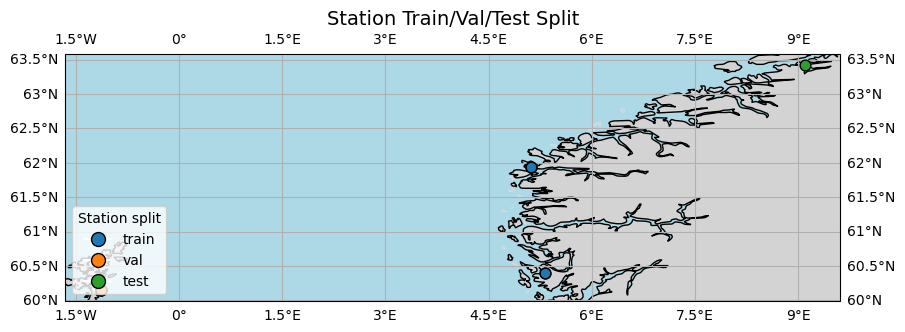

In [ ]:
# pip install cartopy matplotlib

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Station metadata from dataset
stations = ds["station"].values
lats = ds["station_latitude"].values
lons = ds["station_longitude"].values

# Assign split labels
split_labels = []
for st in stations:
    if st in train_stn:
        split_labels.append("train")
    elif st in val_stn:
        split_labels.append("val")
    elif st in test_stn:
        split_labels.append("test")
    else:
        split_labels.append("unknown")

# Map colors
colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:green", "unknown": "gray"}

# Plot
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.gridlines(draw_labels=True)

# Scatter stations
for lat, lon, label in zip(lats, lons, split_labels):
    ax.scatter(lon, lat, color=colors[label], s=60, edgecolor="k", transform=ccrs.PlateCarree(), zorder=5)

# Legend
handles = [plt.Line2D([0], [0], marker="o", color="w", label=lbl,
                      markerfacecolor=col, markersize=10, markeredgecolor="k")
           for lbl, col in colors.items() if lbl != "unknown"]
ax.legend(handles=handles, loc="lower left", title="Station split")

plt.title("Station Train/Val/Test Split", fontsize=14)
plt.show()
